=== Modhupur Forest Cover ADF Test Results ===

ADF Test with 'c' regression:
ADF Statistic: -2.4653
p-value: 0.1242
Critical Values:
   1%: -4.2232
   5%: -3.1894
   10%: -2.7298
Stationary? No

ADF Test with 'ct' regression:
ADF Statistic: -1.9990
p-value: 0.6020
Critical Values:
   1%: -4.6170
   5%: -3.7093
   10%: -3.2973
Stationary? No

ADF Test with 'n' regression:
ADF Statistic: -0.0000
p-value: 0.6843
Critical Values:
   1%: -2.8256
   5%: -1.9703
   10%: -1.5920
Stationary? No


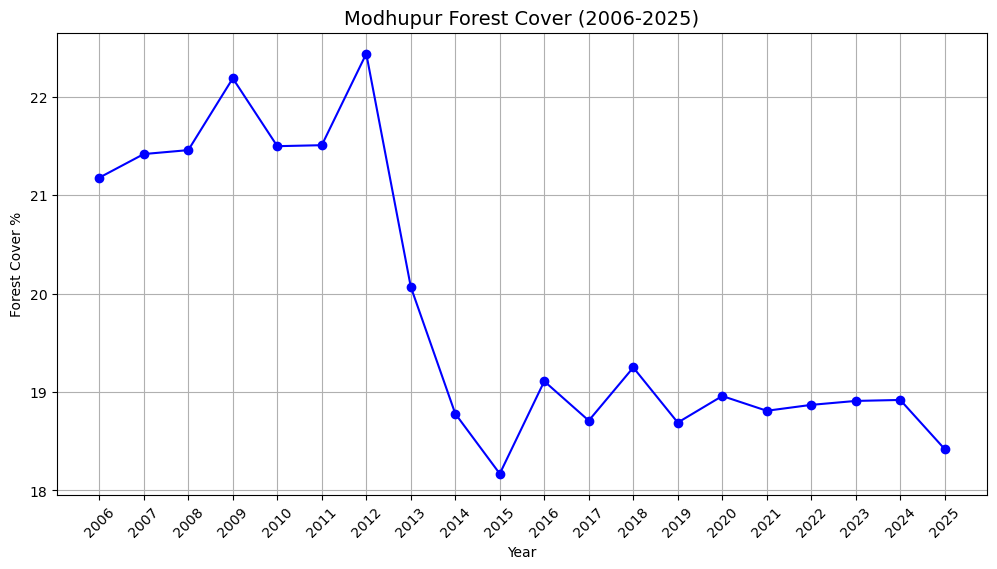

In [3]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# Prepare the data
years = list(range(2006, 2026))
remaining_forest = [
    21.18, 21.42, 21.46, 22.19, 21.50, 21.51, 22.44,
    20.07, 18.78, 18.17, 19.11, 18.71, 19.25,
    18.69, 18.96, 18.81, 18.87, 18.91, 18.92, 18.42
]

forest_series = pd.Series(remaining_forest, index=years)

def adf_test(series, regression_type='ct'):
    """Run ADF test with specified regression type"""
    result = adfuller(series, regression=regression_type, autolag='AIC')
    print(f"\nADF Test with '{regression_type}' regression:")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
    print(f"Stationary? {'Yes' if result[1] < 0.05 else 'No'}")
    return result

# Run all three test variants
print("=== Modhupur Forest Cover ADF Test Results ===")
adf_test(forest_series, 'c')     # Constant only
adf_test(forest_series, 'ct')    # Constant + trend (most appropriate)
adf_test(forest_series, 'n')     # No constant

# Visualize the data
plt.figure(figsize=(12, 6))
plt.plot(forest_series, 'bo-')
plt.title("Modhupur Forest Cover (2006-2025)", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Forest Cover %")
plt.grid(True)
plt.xticks(years, rotation=45)
plt.show()

=== ADF Test Results ===
ADF Statistic: -1.1741
p-value: 0.9157
Critical Values: {'1%': -4.988247662037037, '5%': -3.865364768518518, '10%': -3.382725}
Stationary? False

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.20 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=55.616, Time=0.02 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=53.091, Time=0.03 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.09 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=53.617, Time=0.02 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=53.830, Time=0.03 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.11 sec
 ARIMA(2,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.15 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=51.093, Time=0.02 sec
 ARIMA(2,2,0)(0,0,0)[0]             : AIC=51.842, Time=0.02 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(2,2,1)(0,0,0)[0]             

C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


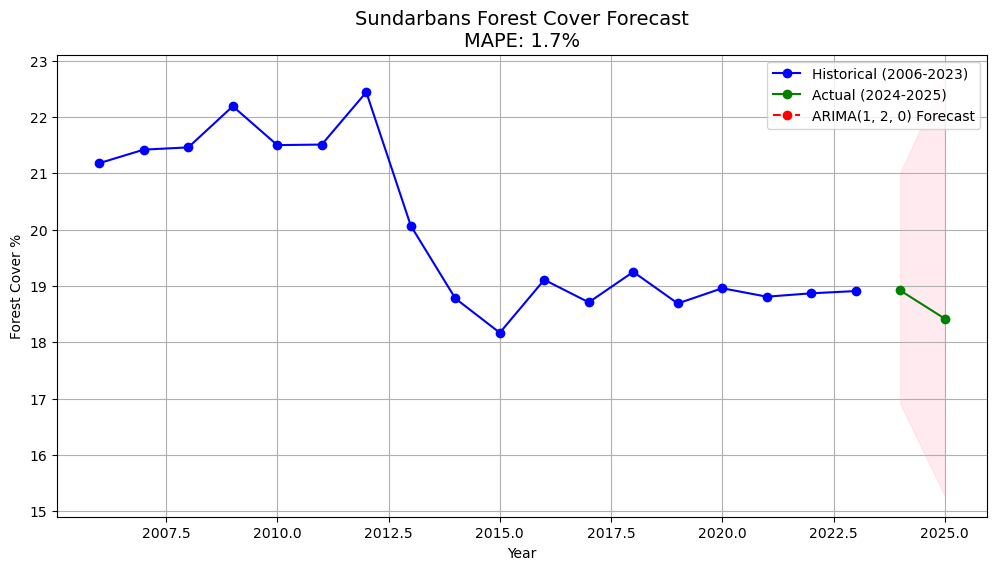


Forecast vs Actual Comparison:
 Year  Actual  Forecast  Lower CI  Upper CI  Error %
 2024   18.92 18.959615 16.910426 21.008804 0.209380
 2025   18.42 19.004607 15.277464 22.731751 3.173763


In [4]:
#deep
import pandas as pd
from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
years = list(range(2006, 2026))
remaining_forest = [
    21.18, 21.42, 21.46, 22.19, 21.50, 21.51, 22.44,
    20.07, 18.78, 18.17, 19.11, 18.71, 19.25,
    18.69, 18.96, 18.81, 18.87, 18.91, 18.92, 18.42
]
actual_2024, actual_2025 = 18.92, 18.42

# Split into train (2006-2023) and test (2024-2025)
train = pd.Series(remaining_forest[:-2], index=years[:-2])
test = pd.Series([actual_2024, actual_2025], index=[2024, 2025])

# ADF Test
def adf_test(series):
    result = adfuller(series, regression='ct')  # Using trend-aware test
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Critical Values: {result[4]}")
    return result[1] < 0.05

print("=== ADF Test Results ===")
is_stationary = adf_test(train)
print(f"Stationary? {is_stationary}\n")

# AutoARIMA Model
model = auto_arima(train,
                  seasonal=False,
                  test='adf',
                  regression='ct',
                  stepwise=True,
                  trace=True,
                  suppress_warnings=True)

print(f"\nOptimal ARIMA Order: {model.order}")
print(f"AIC: {model.aic():.2f}")  # Corrected AIC access

# Forecast
forecast, conf_int = model.predict(n_periods=2, return_conf_int=True)
forecast_series = pd.Series(forecast, index=[2024, 2025])

# Evaluation
errors = forecast - test.values
mape = np.mean(np.abs(errors/test.values))*100

# Visualization
plt.figure(figsize=(12,6))
plt.plot(train, 'bo-', label='Historical (2006-2023)')
plt.plot(test, 'go-', label='Actual (2024-2025)')
plt.plot(forecast_series, 'ro--', label=f'ARIMA{model.order} Forecast')
plt.fill_between(test.index, conf_int[:,0], conf_int[:,1], color='pink', alpha=0.3)
plt.title(f"Sundarbans Forest Cover Forecast\nMAPE: {mape:.1f}%", fontsize=14)
plt.xlabel('Year')
plt.ylabel('Forest Cover %')
plt.legend()
plt.grid(True)
plt.show()

# Results Table
results = pd.DataFrame({
    'Year': [2024, 2025],
    'Actual': [actual_2024, actual_2025],
    'Forecast': forecast,
    'Lower CI': conf_int[:,0],
    'Upper CI': conf_int[:,1],
    'Error %': np.abs(errors/test.values)*100
})
print("\nForecast vs Actual Comparison:")
print(results.to_string(index=False))

=== ADF Test Results ===
ADF Statistic: -1.1741
p-value: 0.9157
Critical Values: {'1%': -4.988247662037037, '5%': -3.865364768518518, '10%': -3.382725}
Stationary? False

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.21 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=55.616, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=53.091, Time=0.03 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.09 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=53.617, Time=0.02 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=53.830, Time=0.03 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.12 sec
 ARIMA(2,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.16 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=51.093, Time=0.02 sec
 ARIMA(2,2,0)(0,0,0)[0]             : AIC=51.842, Time=0.02 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(2,2,1)(0,0,0)[0]             

C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


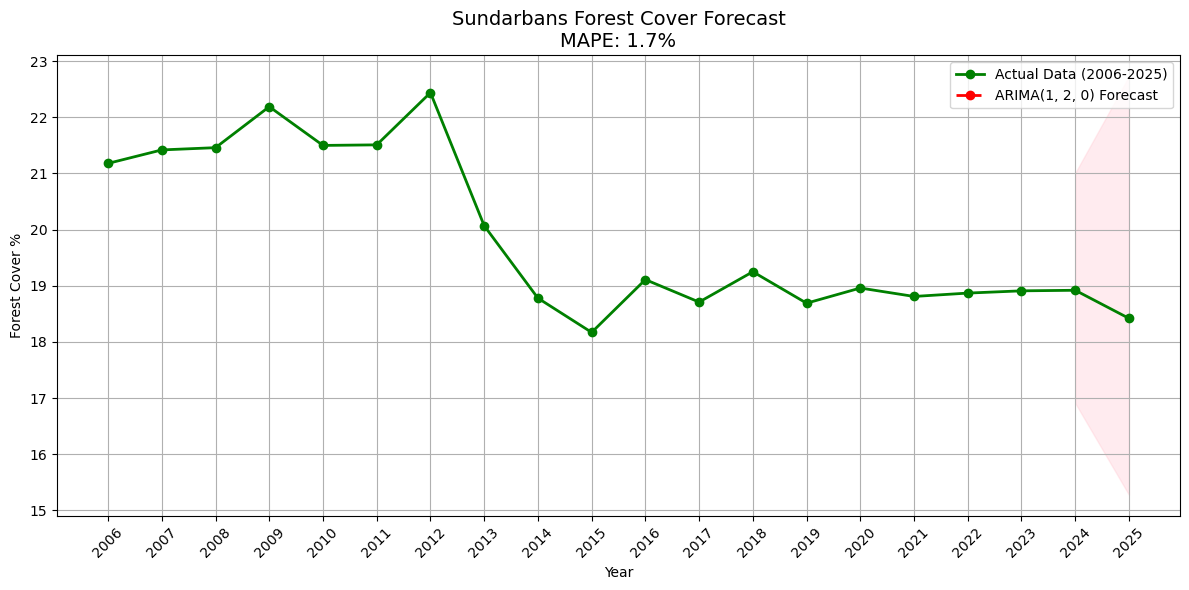


Forecast vs Actual Comparison:
 Year  Actual  Forecast  Lower CI  Upper CI  Error %
 2024   18.92 18.959615 16.910426 21.008804 0.209380
 2025   18.42 19.004607 15.277464 22.731751 3.173763


In [5]:
#deep
import pandas as pd
from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
years = list(range(2006, 2026))
remaining_forest = [
    21.18, 21.42, 21.46, 22.19, 21.50, 21.51, 22.44,
    20.07, 18.78, 18.17, 19.11, 18.71, 19.25,
    18.69, 18.96, 18.81, 18.87, 18.91, 18.92, 18.42
]
actual_2024, actual_2025 = 18.92, 18.42

# Create complete series
full_series = pd.Series(remaining_forest, index=years)
train = full_series[:-2]
test = full_series[-2:]

# ADF Test
def adf_test(series):
    result = adfuller(series, regression='ct')
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Critical Values: {result[4]}")
    return result[1] < 0.05

print("=== ADF Test Results ===")
is_stationary = adf_test(train)
print(f"Stationary? {is_stationary}\n")

# AutoARIMA Model
model = auto_arima(train,
                  seasonal=False,
                  test='adf',
                  regression='ct',
                  stepwise=True,
                  trace=True,
                  suppress_warnings=True)

print(f"\nOptimal ARIMA Order: {model.order}")
print(f"AIC: {model.aic():.2f}")

# Forecast
forecast, conf_int = model.predict(n_periods=2, return_conf_int=True)
forecast_series = pd.Series(forecast, index=test.index)

# Combine actual and forecasted data
combined_actual = full_series.copy()
combined_forecast = pd.concat([train, forecast_series])

# Evaluation
errors = forecast - test.values
mape = np.mean(np.abs(errors/test.values))*100

# Visualization
plt.figure(figsize=(12,6))
plt.xticks(years, rotation=45)  # All years on x-axis

# Plot actual data (2006-2025)
plt.plot(combined_actual.index, combined_actual, 'go-', 
        label='Actual Data (2006-2025)', linewidth=2)

# Plot forecast (2024-2025)
plt.plot(forecast_series.index, forecast_series, 'ro--', 
        label=f'ARIMA{model.order} Forecast', linewidth=2)

plt.fill_between(forecast_series.index, conf_int[:,0], conf_int[:,1], 
                color='pink', alpha=0.3)
plt.title(f"Sundarbans Forest Cover Forecast\nMAPE: {mape:.1f}%", fontsize=14)
plt.xlabel('Year')
plt.ylabel('Forest Cover %')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Results Table
results = pd.DataFrame({
    'Year': [2024, 2025],
    'Actual': test.values,
    'Forecast': forecast,
    'Lower CI': conf_int[:,0],
    'Upper CI': conf_int[:,1],
    'Error %': np.abs(errors/test.values)*100
})
print("\nForecast vs Actual Comparison:")
print(results.to_string(index=False))

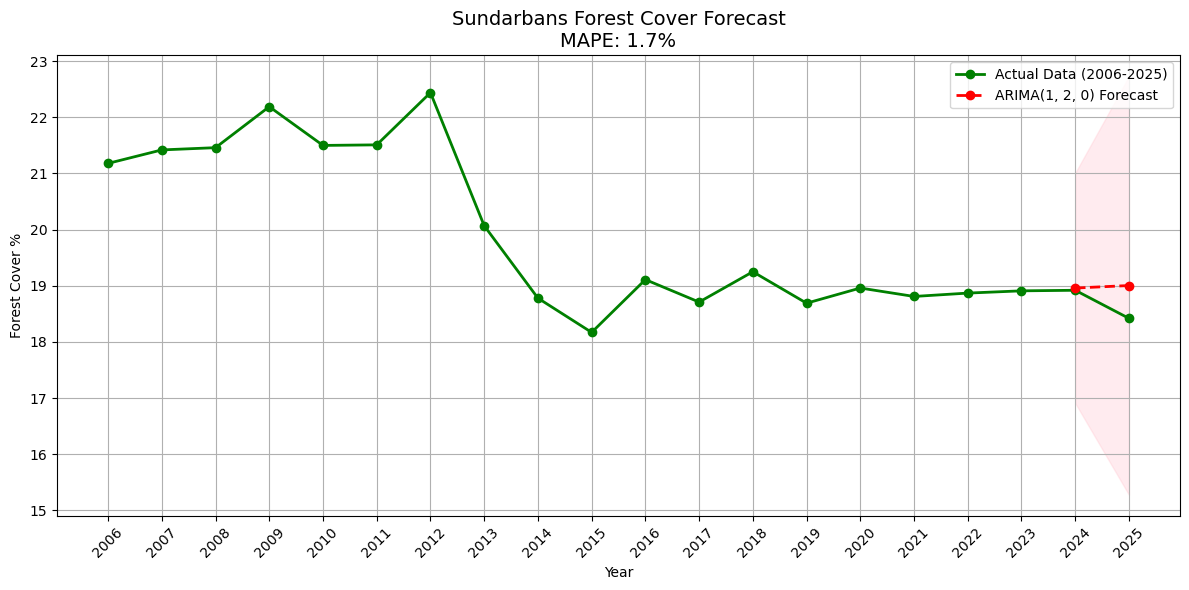

In [6]:
# Visualization
plt.figure(figsize=(12,6))
plt.xticks(years, rotation=45)  # All years on x-axis

# Plot actual data (2006-2025)
plt.plot(full_series.index, full_series, 'go-', 
        label='Actual Data (2006-2025)', linewidth=2)

# Plot forecast (2024-2025) - THIS IS THE CRUCIAL FIX
plt.plot([2024, 2025], forecast, 'ro--', 
        label=f'ARIMA{model.order} Forecast', linewidth=2)

plt.fill_between([2024, 2025], conf_int[:,0], conf_int[:,1], 
                color='pink', alpha=0.3)
plt.title(f"Sundarbans Forest Cover Forecast\nMAPE: {mape:.1f}%", fontsize=14)
plt.xlabel('Year')
plt.ylabel('Forest Cover %')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

=== ADF Test Results ===
ADF Statistic: -1.1741
p-value: 0.9157
Critical Values:
   1%: -4.988
   5%: -3.865
   10%: -3.383

Stationary? False

=== AutoARIMA Model Selection ===
Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.22 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=55.616, Time=0.02 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=53.091, Time=0.03 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.10 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=53.617, Time=0.01 sec
 ARIMA(2,2,0)(0,0,0)[0] intercept   : AIC=53.830, Time=0.03 sec
 ARIMA(1,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.12 sec
 ARIMA(2,2,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.17 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=51.093, Time=0.02 sec
 ARIMA(2,2,0)(0,0,0)[0]             : AIC=51.842, Time=0.02 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=inf, Time=0.10 sec
 ARIMA(2,2,1)(0,0,0)[0]      

C:\Users\Firoz\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


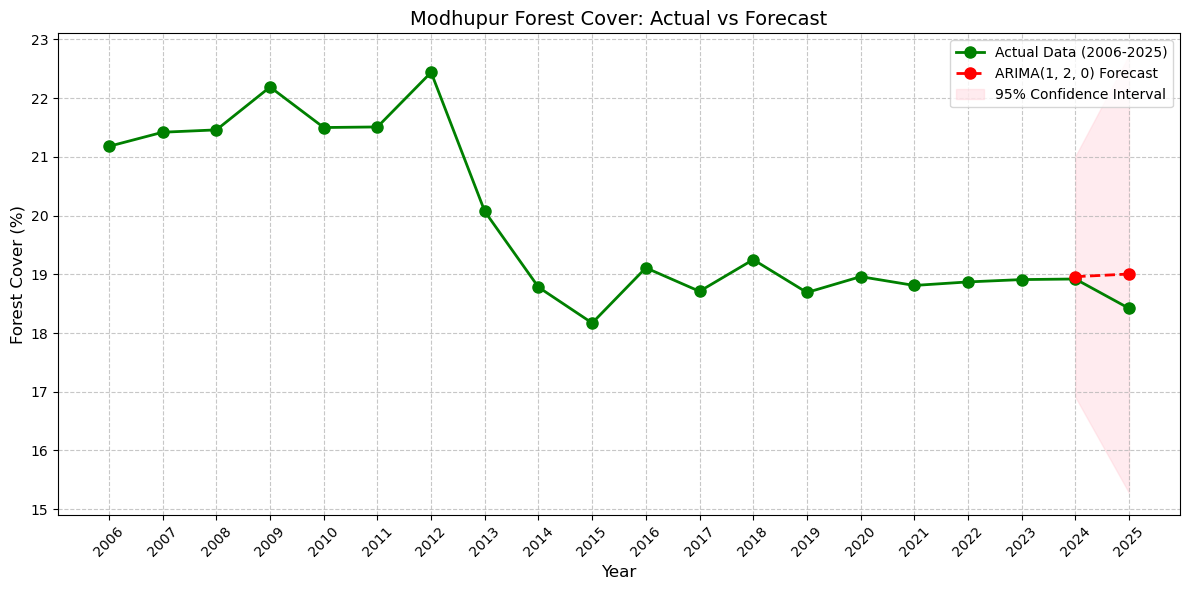

In [8]:
# Deep ARIMA Analysis for Sundarbans Forest Cover
import pandas as pd
from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
years = list(range(2006, 2026))
remaining_forest = [
    21.18, 21.42, 21.46, 22.19, 21.50, 21.51, 22.44,
    20.07, 18.78, 18.17, 19.11, 18.71, 19.25,
    18.69, 18.96, 18.81, 18.87, 18.91, 18.92, 18.42
]
actual_2024, actual_2025 = 18.92, 18.42

# Create complete series
full_series = pd.Series(remaining_forest, index=years)
train = full_series[:-2]  # 2006-2023
test = full_series[-2:]   # 2024-2025

# ADF Test for stationarity
def adf_test(series):
    result = adfuller(series, regression='ct')  # Using trend-aware test
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.3f}")
    return result[1] < 0.05

print("=== ADF Test Results ===")
is_stationary = adf_test(train)
print(f"\nStationary? {is_stationary}\n")

# AutoARIMA Model
print("=== AutoARIMA Model Selection ===")
model = auto_arima(train,
                  seasonal=False,
                  test='adf',
                  regression='ct',
                  stepwise=True,
                  trace=True,
                  suppress_warnings=True)

print(f"\nOptimal ARIMA Order: {model.order}")
print(f"AIC: {model.aic():.2f}")

# Forecast
forecast, conf_int = model.predict(n_periods=2, return_conf_int=True)

# Evaluation
errors = forecast - test.values
mape = np.mean(np.abs(errors/test.values))*100

# Visualization
plt.figure(figsize=(12, 6))
plt.xticks(years, rotation=45)

# Plot actual data (2006-2025)
plt.plot(full_series.index, full_series, 'go-', 
         label='Actual Data (2006-2025)', 
         linewidth=2, markersize=8)

# Plot forecast (2024-2025)
plt.plot([2024, 2025], forecast, 'ro--', 
         label=f'ARIMA{model.order} Forecast', 
         linewidth=2, markersize=8)

# Confidence interval
plt.fill_between([2024, 2025], 
                conf_int[:, 0], conf_int[:, 1],
                color='pink', alpha=0.3, 
                label='95% Confidence Interval')

plt.title('Modhupur Forest Cover: Actual vs Forecast', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Forest Cover (%)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Results Table
results = pd.DataFrame({
    'Year': [2024, 2025],
    'Actual': test.values,
    'Forecast': forecast.round(2),
    'Lower CI': conf_int[:, 0].round(2),
    'Upper CI': conf_int[:, 1].round(2),
    'Error %': (np.abs(errors/test.values)*100).round(1)
})

print("\n=== Forecast Accuracy ===")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.1f}%")
print("\n=== Forecast vs Actual Comparison ===")
print(results.to_string(index=False))

plt.show()